## AGN Homework 7b – Modeling Spectral Energy Distributions

#### Notebook Preamble

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qsosed import SED


Initializing QSOSED model...


/home/fritz/.local/miniforge3/envs/7b/lib/python3.10/site-packages/qsosed/sed.py:80: RuntimeWarning: overflow encountered in exp
  planck_spectrum_exp = np.exp(energy / (const.k_B * T))


Data successfully calculated and saved to 'super_eddington_sed.csv'.

=== WAVEBAND ENERGY DISTRIBUTION BREAKDOWN ===
 Band Name  Energy Distribution (%)
   Optical                     9.71
        UV                    69.20
Soft X-ray                    11.29
Hard X-ray                     0.02



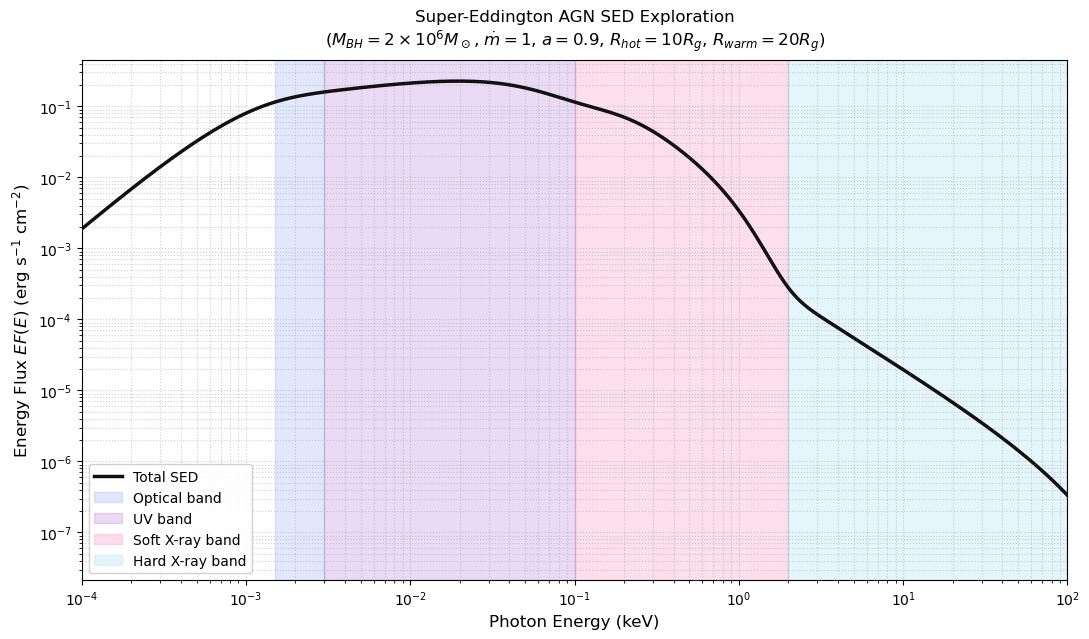

In [1]:

# =============================================================================
# 1. PHYSICAL PARAMETERS (Example 1: Super-Eddington AGN / NLSy1)
# =============================================================================
M_BH = 2e6         # Black hole mass in solar masses (2 x 10^6)
spin = 0.9         # Dimensionless black hole spin (a)
mdot = 1.0         # Mass accretion rate (L_bol / L_Edd)
distance_mpc = 180.0

# Convert luminosity distance from Mpc to cm for the physics engine
distance_cm = distance_mpc * 3.086e24 

# =============================================================================
# 2. MODEL INITIALIZATION & CORONA FIXES
# =============================================================================
print("Initializing QSOSED model...")
model = SED(
    M=M_BH, 
    mdot=mdot, 
    spin=spin, 
    warm_electron_energy=0.2,   # kT_warm in keV
    warm_photon_index=2.5       # Gamma_warm
)

# Explicitly fix the corona radii constraints given in your prompt
model.hot_radius = 10.0        # Rhot = 10 Rg
model.warm_radius = 20.0       # Rwarm = 20 Rg

# =============================================================================
# 3. DATA EXTRACTION & PANDAS STORAGE
# =============================================================================
# Extract internal energy grid (keV) and calculate total flux E*F(E)
energy_grid = model.ENERGY_RANGE_KEV
flux_values = model.total_flux(distance_cm)

# Create a clean Pandas DataFrame for easy data manipulation/saving
df = pd.DataFrame({
    'Energy_keV': energy_grid,
    'Flux_EF_E': flux_values
})

# Save raw SED data to CSV for future homework comparisons
df.to_csv('super_eddington_sed.csv', index=False)
print("Data successfully calculated and saved to 'super_eddington_sed.csv'.")

# =============================================================================
# 4. ENERGY DISTRIBUTION ANALYSIS (Waveband Exploration)
# =============================================================================
# Define standard astronomical wavebands in keV
wavebands = {
    'Optical': (1.5e-3, 3e-3),
    'UV': (3e-3, 0.1),
    'Soft X-ray': (0.1, 2.0),
    'Hard X-ray': (2.0, 100.0)
}

band_fluxes = {}
total_integrated_flux = df['Flux_EF_E'].sum()

# Calculate the energy fraction distributed into each band
for band, (low, high) in wavebands.items():
    mask = (df['Energy_keV'] >= low) & (df['Energy_keV'] <= high)
    band_fluxes[band] = df.loc[mask, 'Flux_EF_E'].sum()

# Display the energy distribution breakdown using a Pandas DataFrame
summary_df = pd.DataFrame({
    'Band Name': band_fluxes.keys(),
    'Integrated Flux Share': band_fluxes.values()
})
summary_df['Energy Distribution (%)'] = (summary_df['Integrated Flux Share'] / total_integrated_flux) * 100

print("\n=== WAVEBAND ENERGY DISTRIBUTION BREAKDOWN ===")
print(summary_df[['Band Name', 'Energy Distribution (%)']].to_string(index=False, float_format="%.2f"))
print("==============================================\n")

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
plt.figure(figsize=(11, 6.5))

# Plot the total spectral energy distribution
plt.loglog(df['Energy_keV'], df['Flux_EF_E'], color='#111111', lw=2.5, label='Total SED')

# Highlight and shade operational bands using the dictionary boundaries
colors = {'Optical': '#4361ee', 'UV': '#7209b7', 'Soft X-ray': '#f72585', 'Hard X-ray': '#4cc9f0'}
for band, (low, high) in wavebands.items():
    plt.axvspan(low, high, color=colors[band], alpha=0.15, label=f'{band} band')

# Plot styling and axis tuning
plt.title(f"Super-Eddington AGN SED Exploration\n"
          f"($M_{{BH}} = 2\\times 10^6 M_\\odot$, $\\dot{{m}}=1$, $a={spin}$, $R_{{hot}}=10R_g$, $R_{{warm}}=20R_g$)", 
          fontsize=12, pad=10)
plt.xlabel("Photon Energy (keV)", fontsize=12)
plt.ylabel("Energy Flux $E F(E)$ ($\mathrm{erg\ s^{-1}\ cm^{-2}}$)", fontsize=12)

plt.xlim(1e-4, 1e2)
# Dynamically scale Y-axis to clip out unphysical zero-flux baselines beautifully
plt.ylim(df.loc[df['Flux_EF_E'] > 0, 'Flux_EF_E'].min() * 0.5, df['Flux_EF_E'].max() * 2)

plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

# Save the high-resolution plot for your report
plt.savefig('super_eddington_sed.png', dpi=300)
plt.show()